# Integrate ATAC & RNA as if they were seperate single-omic experiments

In [1]:
here::i_am("revision/05_unimodal_integration/01_ATAC_mapping.ipynb")

suppressPackageStartupMessages({
    library(data.table)
    library(dplyr)
    library(SingleCellExperiment)
    library(ggpubr)
    library(stringr)
    library(parallel)
    library(purrr) # might not be needed if I rewrite Ricard's code
    library(ArchR)
})
addArchRVerbose(verbose = FALSE)

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))
source(here::here('revision/insilico_chip/utils.R'))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,

In [2]:
###################
## Load settings ##
###################
args = list()
args$archr_directory <- file.path(io$basedir,"data/processed/atac/archR")
args$rna.sce <-file.path(io$basedir,"data/processed/rna/SingleCellExperiment.rds")
args$atac.sce = file.path(io$basedir,"data/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds")
args$metadata <- file.path(io$basedir,"/results/atac/archR/qc/sample_metadata_after_qc.txt.gz")

#
io$motifmatcher <- file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP-Scores.rds")
io$motif2gene <- file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP_motif2gene.txt.gz")
io$background_peaks = file.path(io$basedir,"/data/processed/atac/archR/Background-Peaks.rds")

In [3]:
##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE & pass_atacQC==TRUE & !sample %in% c('E8.5_CRISPR_T_KO','E8.5_CRISPR_T_WT')]

nrow(sample_metadata)

[1] 45713

In [4]:
#### ATAC metadata has cells that are not present in RNA....?
# Quick fix below
atac_metadata <- fread(args$metadata) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE & pass_atacQC==TRUE & !sample %in% c('E8.5_CRISPR_T_KO','E8.5_CRISPR_T_WT')]

nrow(atac_metadata)

rna_metadata <- fread(file.path(io$basedir,"/results/rna/mapping/sample_metadata_after_mapping.txt.gz")) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE & !sample %in% c('E8.5_CRISPR_T_KO','E8.5_CRISPR_T_WT')]
nrow(rna_metadata)

sample_metadata = rna_metadata[match(atac_metadata$cell, cell)]
# 499 cells dissapear
nrow(sample_metadata[is.na(sample_metadata$cell)])
sample_metadata = sample_metadata[!is.na(sample_metadata$cell)]
nrow(sample_metadata)

[1] 45713

[1] 52051

[1] 499

[1] 45214

In [5]:
detectCores()

[1] 32

In [6]:
########################
## Load ArchR Project ##
########################

setwd(args$archr_directory)

addArchRGenome("mm10")
addArchRThreads(threads = 22) 

ArchRProject <- loadArchRProject(args$archr_directory)

# Subset to cells that pass QC
ArchRProject <- ArchRProject[sample_metadata$cell]

Setting default genome to Mm10.

Setting default number of Parallel threads to 22.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\_

In [7]:
########################
## Load RNA SCE
########################

rna.sce <- load_SingleCellExperiment(
  file = args$rna.sce, 
  normalise = FALSE, 
  cells = sample_metadata$cell, 
  remove_non_expressed_genes = TRUE
)

colData(rna.sce) = sample_metadata %>% as.data.frame %>% tibble::column_to_rownames('cell') %>% DataFrame


# I think this needs to be converted to a rangedSummarizedExperiment if I remember correctly

Loading required package: scuttle



In [8]:
ArchRProject
rna.sce


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/atac/archR 
samples(11): E7.5_rep1 E7.5_rep2 ... E8.5_CRISPR_T_KO E8.5_CRISPR_T_WT
sampleColData names(1): ArrowFiles
cellColData names(35): Sample TSSEnrichment ... ReadsInPeaks FRIP
numberOfCells(1): 45214
medianTSS(1): 16.354
medianFrags(1): 30381

class: SingleCellExperiment 
dim: 23745 45214 
metadata(0):
assays(1): counts
rownames(23745): Xkr4 Gm1992 ... CAAA01147332.1 AC149090.1
rowData names(0):
colnames(45214): E7.5_rep1#AAACAGCCATCCTGAA-1
  E7.5_rep1#AAACAGCCATGCTATG-1 ... E8.75_rep2#TTTGTTGGTTCACTGT-1
  E8.75_rep2#TTTGTTGGTTGAGCCG-1
colData names(14): barcode sample ... celltype.score closest.cell
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [9]:
ArchRProject = addIterativeLSI(
    ArchRProj = ArchRProject,
    useMatrix = "PeakMatrix", 
    name = "IterativeLSI", 
    iterations = 2, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(0.2), 
        sampleCells = 10000, 
        n.start = 10
    ), 
    varFeatures = 50000, 
    dimsToUse = 1:50,
    force=T
)

Checking Inputs...



In [10]:
ArchRProject <- addGeneIntegrationMatrix(
    ArchRProj = ArchRProject, 
    useMatrix = "GeneScoreMatrix_distal",
    matrixName = "GeneIntegrationMatrix",
    reducedDims = "IterativeLSI",
    seRNA = rna.sce,
    addToArrow = FALSE,
    groupRNA = "celltype",
    nameCell = "closest_cell",
    nameGroup = "celltype_mapped",
    nameScore = "celltype_Score"
)

Length of unique values greater than palette, interpolating..

Length of unique values greater than palette, interpolating..

Length of unique values greater than palette, interpolating..

Length of unique values greater than palette, interpolating..

Length of unique values greater than palette, interpolating..



In [11]:
meta = as.data.table(ArchRProject@cellColData, keep.rownames=T) %>% 
    setnames('rn', 'cell') %>%
    .[, `:=`(stage_original = str_split(Sample, '_') %>% map_chr(1),
            stage_mapped = str_split(closest_cell, '_') %>% map_chr(1))]

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [13]:
# Plot mapped vs actual cell-types
proportions = copy(meta) %>%
    setnames('celltype.mapped', 'celltype') %>% 
    .[,c('celltype', 'celltype_mapped')] %>% 
    .[, Ntot := .N, by = 'celltype'] %>% 
    .[, N := .N, by = c('celltype', 'celltype_mapped')] %>% 
    unique(by = c('celltype', 'celltype_mapped')) %>%
    .[, prop := N/Ntot]

combinations <- as.data.table(expand.grid(unique(proportions$celltype), unique(proportions$celltype_mapped))) %>%
    setnames(c('Var1', 'Var2'), c('celltype', 'celltype_mapped'))
proportions = merge(combinations, proportions, all.x=T) %>% 
    .[, prop:=ifelse(is.na(prop), 0, prop)]

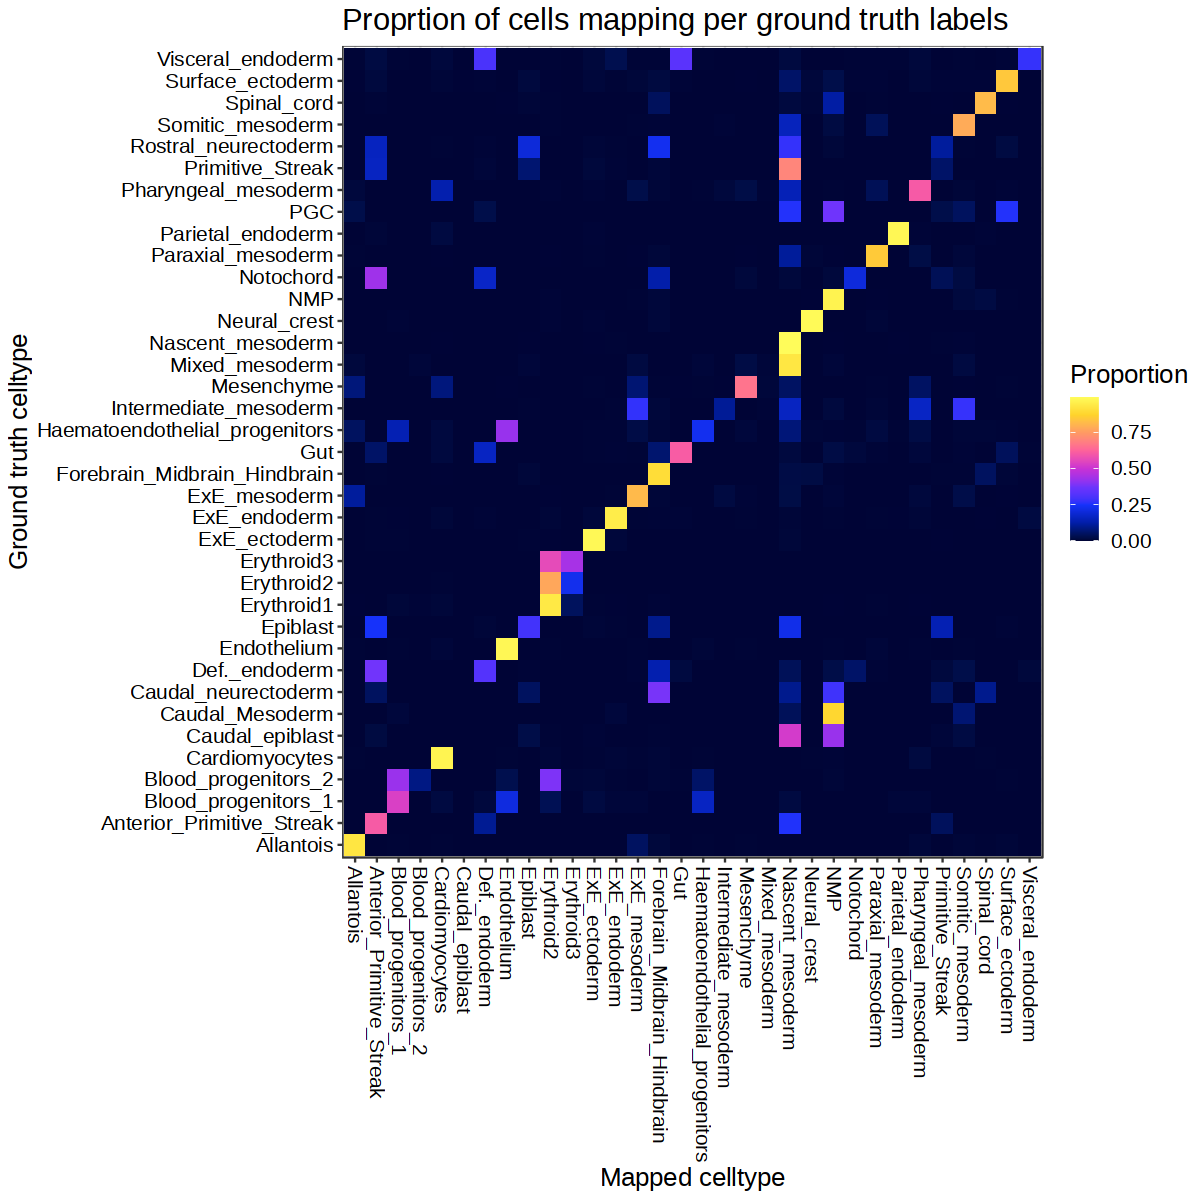

In [14]:
options(repr.plot.width=10, repr.plot.height=10)
ggplot(proportions, aes(celltype_mapped, celltype, fill=prop)) +
    geom_tile() +
    scale_fill_gradientn(colours=ArchR::ArchRPalettes$horizonExtra, name='Proportion')+
    ggtitle('Proprtion of cells mapping per ground truth labels') + 
    xlab('Mapped celltype') + ylab('Ground truth celltype') + 
    theme_bw() + 
    theme(text=element_text(color='black', size=15),
          axis.text = element_text(color='black', size=12),
          axis.text.x = element_text(angle=-90, hjust=0, vjust=0.5))

### Pseudobulk by (mapped) celltype

In [15]:
atac.sce <- load_SingleCellExperiment(
  file = args$atac.sce, 
  normalise = FALSE, 
  cells = meta$cell, 
  remove_non_expressed_genes = FALSE
)

colData(atac.sce) = meta %>% as.data.frame %>% tibble::column_to_rownames('cell') %>% DataFrame

In [16]:
library(BiocParallel)
BPPARAM = MulticoreParam(detectCores())

# Compare Ricards function with just this
rna.pb = aggregateAcrossCells(rna.sce, id=colData(rna.sce)$celltype, BPPARAM = BPPARAM)
assayNames(atac.sce) <- "counts"
atac.pb = aggregateAcrossCells(atac.sce, id=colData(atac.sce)$celltype_mapped, BPPARAM = BPPARAM)

rna.sce_old = rna.sce
atac.sce_old = atac.sce

rna.sce = rna.pb
atac.sce = atac.pb

rna.sce = rna.sce[,match(colnames(atac.sce), colnames(rna.sce))]
summary(colnames(rna.sce) == colnames(atac.sce))

assay(rna.sce,"logcounts") <- log(1e6*(sweep(assay(rna.sce),2,colSums(assay(rna.sce),na.rm=T),"/"))+1)
assay(atac.sce,"logcounts") <- log(1e6*(sweep(assay(atac.sce),2,colSums(assay(atac.sce),na.rm=T),"/"))+1)

   Mode    TRUE 
logical      32 

In [17]:
#######################
## Load Motifs
#######################
motifmatcher.se <- readRDS(io$motifmatcher)

# Subset peaks
stopifnot(sort(rownames(motifmatcher.se))==sort(rownames(atac.sce)))
motifmatcher.se <- motifmatcher.se[rownames(atac.sce),]

motif2gene.dt <- fread(io$motif2gene)

###################
## Correlate TF-expr & Region-accessibility
###################  
tf2peak_cor.se = cor_TF_acc(rna.sce, 
                          atac.sce, 
                          TFs_filt = c('CDX2', 'TAL1', 'GATA1', 'FOXA2', 'GATA4', 'TBX5'), #str_split(colnames(motifmatcher.se), '_') %>% map_chr(1),  # c('SOX17', 'MYBL1') -> test runs
                          motifmatcher.se = motifmatcher.se, 
                          motif2gene.dt = motif2gene.dt,
                          correlation_method = "pearson", #"spearman", # Options for which corrleation method to use
                          remove_motifs = c("T_789"),
                          cores = detectCores()/2)

######################################
## Create virtual chip-seq library 
######################################
motifmatcher_chip = silico_chip(atac.sce = atac.sce, 
                           tf2peak_cor.se = tf2peak_cor.se,
                           motifmatcher.se = motifmatcher.se,
                           motif2gene.dt = motif2gene.dt, 
                           min_number_peaks = 50,
                           TFs_filt = c('CDX2', 'TAL1', 'GATA1', 'FOXA2', 'GATA4', 'TBX5'), 
                           remove_motifs = c("T_789"),
                           cores = detectCores()/2)

[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 6 TFs



[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 6"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


In [18]:
motifmatcher_chip.se = motifmatcher_chip$motifmatcher_chip.se
virtual_chip.dt = motifmatcher_chip$virtual_chip.dt

In [19]:
######################################
## silico_chipseq_validation
######################################
library(GenomicRanges)
library(rtracklayer)

io$chip_dir.prefix <- "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/revisions/chip_files"
io$chip.files <- c(
  "CDX2" = file.path(io$chip_dir.prefix, "GSM2253707_Cdx2_wtEpiSCs_24h_rep1_mm10.bw"),
  "TAL1" = file.path(io$chip_dir.prefix, "GSM1692858_HP_Tal1.bw"),
  "GATA1" = file.path(io$chip_dir.prefix, "GSM1692851_HP_Gata1.bw"),
  "FOXA2" = file.path(io$chip_dir.prefix, "Foxa2.d5FS.bw"),
  "GATA4" = file.path(io$chip_dir.prefix, "GSM3223330_Gata4.d5FS.r1_m1.ucsc.bigWig"),
  "TBX5" = file.path(io$chip_dir.prefix, "Tbx5_WT_CP.bw")
)
peaks = rownames(atac.sce)
peak_metadata.gr <- GRanges(
    seqnames = Rle(peaks %>% str_split(':') %>% map_chr(1)),
    ranges = IRanges(start = as.numeric(peaks %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(1)), 
                     end = as.numeric(peaks %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(2))),
    strand = Rle(rep('*', length(peaks))))

stopifnot(file.exists(io$chip.files))
TFs <- names(io$chip.files)

## calculate background ChIP signal 
chip_background.dt <- TFs %>% map(function(i) {
  data.table(
    chip_anno = i,
    median = median(import.bw(BigWigFile(io$chip.files[[i]]))$score)
  )
}) %>% rbindlist

## calculate signal 
peak_metadata_ucsc.gr <- peak_metadata.gr; seqlevelsStyle(peak_metadata_ucsc.gr) <- 'UCSC'
peak_metadata_ncbi.gr <- peak_metadata.gr; seqlevelsStyle(peak_metadata_ncbi.gr) <- 'NCBI'
tf2seqstyle <- rep("UCSC",length(TFs)); names(tf2seqstyle) <- TFs
tf2seqstyle["TBX5"] <- "NCBI"

to.plot <- mclapply(TFs, function(i){
  # Load virtual ChIP-seq library
    virtual_chip_tmp = copy(virtual_chip.dt)[tf==i] %>% 
        setnames('peak', 'idx') %>% 
        .[,idx:=str_replace(idx,":","-")] %>%
        .[,chr:=strsplit(idx,"-") %>% map_chr(1)] %>%
        .[,start:=as.integer(strsplit(idx,"-") %>% map_chr(2))] %>%
        .[,end:=as.integer(strsplit(idx,"-") %>% map_chr(3))] %>%
        .[,idx:=str_replace(idx,"-",":")] %>% 
        setkey(chr,start,end)

    # Load ground truth ChIP-seq data
    if (tf2seqstyle[[i]]=="UCSC") {
        tmp <- peak_metadata_ucsc.gr
    } else if (tf2seqstyle[[i]]=="NCBI") {
        tmp <- peak_metadata_ncbi.gr
    }

    chip.dt <- import.bw(BigWigFile(io$chip.files[[i]]), selection = tmp) %>% as.data.table %>%
        .[,c(1,2,3,6)] %>% setnames(c("chr", "start", "end","value")) %>%
        .[,chr:=as.character(chr)] %>%
        .[,chr:=ifelse(grepl("chr",chr),chr,paste0("chr",chr))] %>%
      setkey(chr,start,end)

      # overlap ATAC peaks with ChIP-seq signal and quantify ChIP signal
    to.plot =  virtual_chip_tmp[,c("idx","chr","start","end")] %>%
        foverlaps(chip.dt, nomatch=0) %>% 
        .[,.(value=sum(value)), b=c("idx")] %>%
        merge(virtual_chip_tmp[,c("idx","score","motif_score", "max_accessibility_score")]) %>%
        .[,chip_anno:=as.factor(i)] %>%
        return
  
}, mc.cores=10) %>% rbindlist

seq.ranges <- seq(0,1,by=0.10); names(seq.ranges) <- as.character(1:length(seq.ranges))

foo <- to.plot %>%
  .[score>=0] %>% 
  merge(chip_background.dt,by="chip_anno") %>%
  .[,log_value:=log(value+1)] %>%
  .[,c("chip_anno","idx","log_value","motif_score","score", "max_accessibility_score")] %>%
  setnames("score","score_rna_atac")

to.plot.compare_models <- foo %>%
  # Model 1: DNA
  # .[,score_dna:=minmax.normalisation(motif_score), by="chip_anno"] %>% 
  # Model 2: DNA + ATAC
  .[,score_dna_atac:=minmax.normalisation(max_accessibility_score * motif_score), by="chip_anno"] %>% .[,score_dna_atac:=score_dna_atac+0.001] %>%
  # Model 3: DNA + ATAC + RNA
  .[,score_rna_atac:=minmax.normalisation(score_rna_atac), by="chip_anno"] %>% .[,score_rna_atac:=score_rna_atac+0.001] %>%
  # Discretise values
  # .[,score_dna_group:=cut(abs(score_dna), breaks=seq.ranges)] %>% .[,score_dna_group:=seq.ranges[as.numeric(score_dna_group)]] %>%
  .[,score_dna_atac_group:=cut(abs(score_dna_atac), breaks=seq.ranges)] %>% .[,score_dna_atac_group:=seq.ranges[as.numeric(score_dna_atac_group)]] %>%
  .[,score_rna_atac_group:=cut(abs(score_rna_atac), breaks=seq.ranges)] %>% .[,score_rna_atac_group:=seq.ranges[as.numeric(score_rna_atac_group)]] %>%
  # Prepare for plotting
  melt(id.vars=c("chip_anno","idx","log_value"), measure.vars=c("score_dna_atac_group","score_rna_atac_group"), variable.name="model", value.name="predicted_value") %>%
  .[,N:=.N,by=c("model","chip_anno","predicted_value")] %>%
  .[,.(mean=mean(log_value,na.rm=T), sd=sd(log_value,na.rm=T), N=.N), by=c("model","chip_anno","predicted_value")] %>%
  # Filter settings with a small number of observations
  .[!is.na(mean) & N>=25]

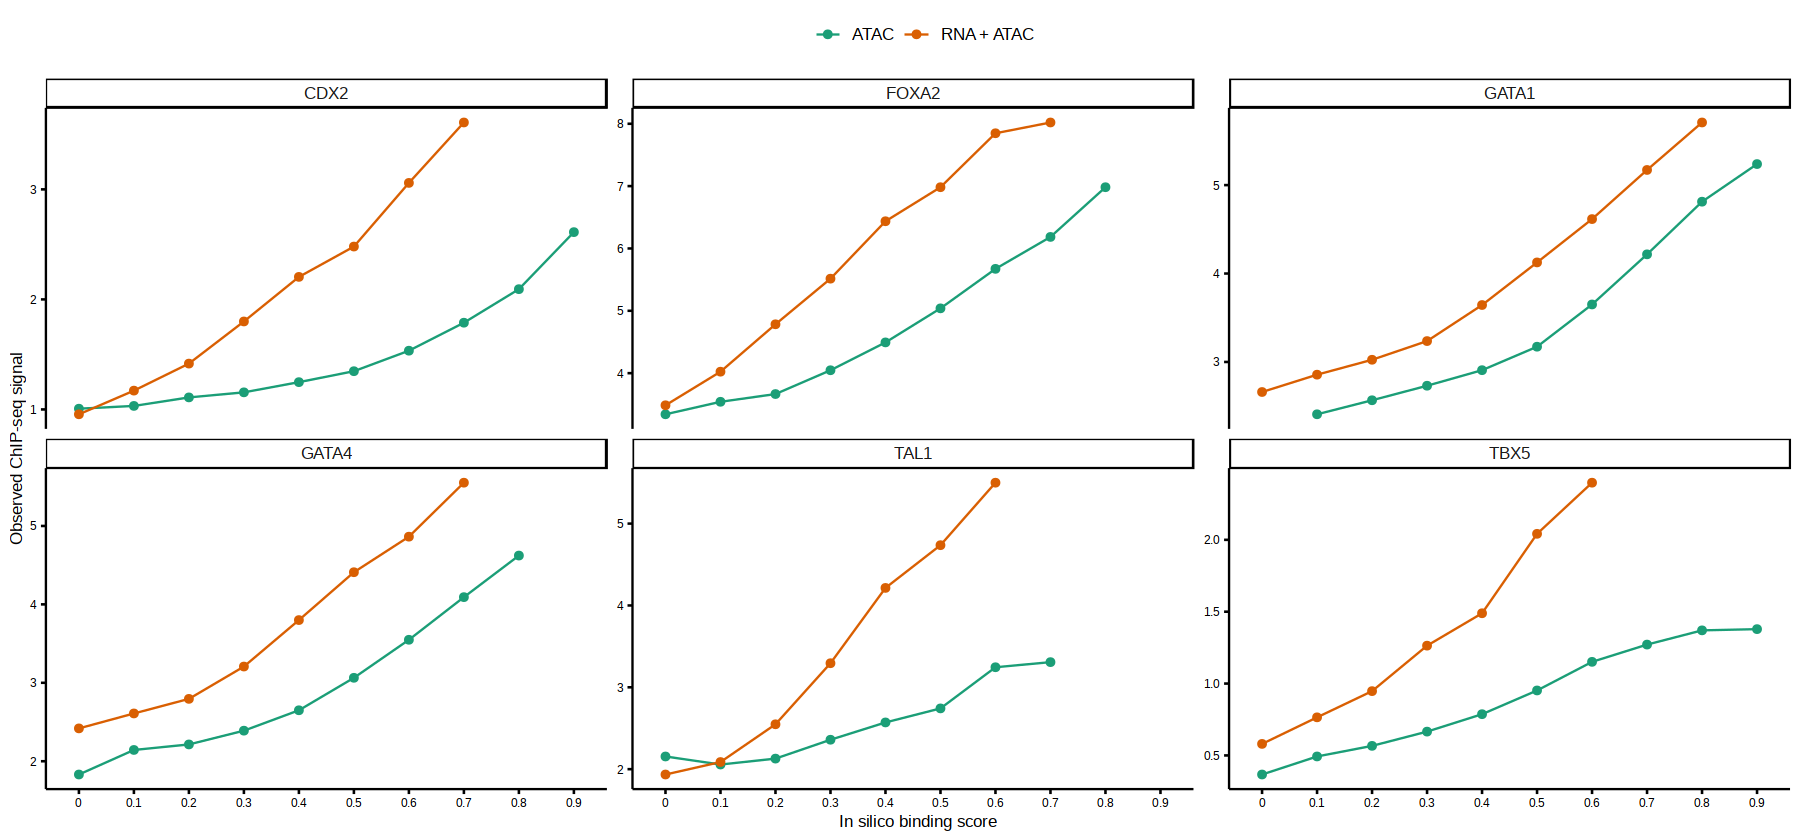

In [21]:
options(repr.plot.width=15, repr.plot.height=7)
ggline(to.plot.compare_models, x="predicted_value", y="mean", color="model", plot_type="b") +
  facet_wrap(~chip_anno, scales="free_y") +
  # geom_errorbar(aes(ymin=log_value-sd, ymax=log_value-sd), width=.2,) +
  scale_color_brewer(palette="Dark2", labels = c("ATAC", "RNA + ATAC")) +
  # scale_color_discrete(labels = c("DNA", "DNA + ATAC", "DNA + ATAC + RNA")) +
  labs(y="Observed ChIP-seq signal", x="In silico binding score") +
  theme(
    strip.background = element_rect(colour="black", fill=NA),
    axis.text = element_text(size=rel(0.55)),
    axis.title = element_text(size=rel(0.8)),
    legend.title = element_blank(),
    # legend.position = c(.26,.87)
    # legend.position = c(.06,.94)
    legend.position = "top"
  )

In [28]:
foo

chip_anno,idx,log_value,motif_score,score_rna_atac,max_accessibility_score,score_dna_atac,score_dna_atac_group,score_rna_atac_group
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CDX2,chr10:100023695-100024295,4.9698896,0.95,0.15484615,1.83,0.3058679,0.3,0.1
CDX2,chr10:100034910-100035510,1.0010546,0.88,0.13946154,2.19,0.3582380,0.3,0.1
CDX2,chr10:100042137-100042737,0.9003117,1.00,0.04715385,2.27,0.4533757,0.4,0.0
CDX2,chr10:100065912-100066512,3.6452232,1.00,0.24715385,2.96,0.6448721,0.6,0.2
CDX2,chr10:10038933-10039533,1.2387597,0.89,0.04715385,2.18,0.3618459,0.3,0.0
CDX2,chr10:100754791-100755391,2.3506464,0.84,0.04715385,1.39,0.1474254,0.1,0.0
CDX2,chr10:100921553-100922153,2.0105335,1.00,0.50869231,2.29,0.4589263,0.4,0.5
CDX2,chr10:100940445-100941045,0.4534422,0.88,0.21638462,2.22,0.3655648,0.3,0.2
CDX2,chr10:10136541-10137141,0.2317385,0.90,0.23176923,2.19,0.3703939,0.3,0.2


In [23]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/atac/archR"

In [27]:
save_bed = function(TF, score_thr=1e-10, abs=TRUE){
    peaks = rownames(motifmatcher_chip.se)
    tmp = data.table(chr = str_split(peaks, ':') %>% map_chr(1),
                     start = str_split(str_split(peaks, ':') %>% map_chr(2), '-') %>% map_chr(1),
                     end = str_split(str_split(peaks, ':') %>% map_chr(2), '-') %>% map_chr(2),
                     score = as.matrix(assay(motifmatcher_chip.se[,TF], 'VirtualChipScores'))) %>%
        setnames(c('chr', 'start', 'end', 'score'))
    if(abs){
        tmp = tmp[abs(score)>=score_thr] 
    }else{
        tmp = tmp[score>=score_thr] 
    }
    fwrite(tmp, sprintf('%s/code/revision/05_unimodal_integration/%s.bed.gz', io$basedir, TF), col.names=F, sep='\t')
    return(tmp)    
}

beds = mclapply(c('CDX2', 'TAL1', 'GATA1', 'FOXA2', 'GATA4', 'TBX5'), save_bed, score_thr=1e-10, abs=TRUE, mc.cores=3) %>% rbindlist()
